# Model 8 — Insurance Premium Estimator (Linear Regression)

## Question
> Given a car's technical specifications and damage history — what average insurance (kasko) premium should the owner expect to pay?

## Introduction
This notebook builds a **regression model** to predict average kasko (insurance) premiums.

- **Dataset**: Unscaled data (`proceed_dataset_without_scaling.csv`)
- **Target variable**: `Ortalama Kasko` (average insurance premium in TL)
- **Algorithm options**: You may use `LinearRegression`, `Ridge`, `Lasso`, or even tree-based/ensemble methods for this task.
- **Special note**: If `paint_damage_score` and `total_changed_parts` appear as strong coefficients/importances, it validates Team 3's engineered damage features — be sure to highlight this in your presentation.
- **Feature flexibility**: You may choose different features, add new features, or tune hyperparameters — but you cannot change the general technique category.

### 1. Data Import

The cell below loads all required libraries and the dataset. **Run this cell as-is** — it is provided and complete.

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv('https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/proceed_dataset_without_scaling.csv')
print(f"Dataset shape: {df.shape}")

target_col = 'Ortalama Kasko'
if target_col in df.columns:
    print(f"Target column '{target_col}': {df[target_col].notna().sum()} non-null values")
    print(f"Range: {df[target_col].min():,.0f} — {df[target_col].max():,.0f} TL")
else:
    print(f"WARNING: Target column '{target_col}' not found.")
    print(f"Available columns: {[c for c in df.columns if 'Kasko' in c or 'kasko' in c]}")


Dataset shape: (2589, 87)
Target column 'Ortalama Kasko': 2589 non-null values
Range: 9 — 11 TL


### 2. Feature Selection

**TODO — Student task:** Review the recommended features below. You may keep them, remove some, or add others from the dataset. After finalizing your features, run this cell to prepare training and test sets.

In [168]:
# 🔹 Araç yaşı oluştur
df["Araç Yaşı"] = 2026 - df["Yıl"]

# Korelasyon analizine göre seçilmiş feature'lar
features_base = [
    "İlan Tarihi",
    "Tork",
    "Genişlik",
    "Motor Gücü",
    "Boş Ağırlığı",
    "Hızlanma (0-100)",
    "Jant Boyutu",
    "Seri",
    "Yakıt Deposu",
    "Yükseklik",
    "Model",
    "Maksimum Güç",
    "Uzunluk",
    "Sınıfı",
    "Fiyat",
    "Maksimum Hız",
    "Şehir İçi Yakıt Tüketimi",
    "Minimum Güç",
    "Aks Aralığı",
    "Motor Hacmi",
    "Araç Yaşı",
    "Kilometre",
    "paint_damage_score",
    "total_changed_parts",
    "is_fully_original",
]
features_base += [col for col in df.columns if "Kasa Tipi_" in col]
features_base += [col for col in df.columns if "Çekiş_" in col]
features_base += [col for col in df.columns if "Yakıt Tipi_" in col]

X = df[features_base]
y = df["Ortalama Kasko"]  # Log dönüşümlü değer


In [169]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


### 3. Model Training

**TODO — Student task:** This cell is a placeholder. The structure (instantiate → fit → predict) is correct — you may change the model type or tune hyperparameters.

In [170]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


### 4. Evaluation Metrics

The cell below computes RMSE, MAE, and R² on the test set. These are the primary metrics for your report.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual model outputs after training.

In [171]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"--- Log uzayında ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")


--- Log uzayında ---
RMSE: 0.0681
MAE:  0.0515
R²:   0.6788


### metrik değerleri garip çıktı çünkü veri ön işlemede outlier değerler için log dönüşümü yapmıştık. şimdi daha normal sonuçlar alabilmek için,

## log dönüşümünü geri alıyorum


In [172]:
# ✅ Ortalama Kasko log dönüşümlü — expm1 ile gerçek TL'ye çevir
y_pred_real = np.expm1(y_pred)
y_test_real = np.expm1(y_test)


In [173]:
# ⚠️ Replace y_test and y_pred with your actual outputs after training.
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae = mean_absolute_error(y_test_real, y_pred_real)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.2f} TL")
print(f"MAE:  {mae:,.2f} TL")
print(f"R²:   {r2:.4f}")

RMSE: 1,079.24 TL
MAE:  816.23 TL
R²:   0.6788


şimdi sonuçlar daha anlaşılır.. modelin ortalama mutlak hatası 816 TL (MAE).
tahminde 1000 tl civarında sapma yapıyor (RMSE)
ve model veri setinin %67'sini anlıyor (R2)



> Modelin performansı ortalama



### Gelişmiş model: Outlier temizliği + türetilmiş özellikler + Polynomial + Ridge

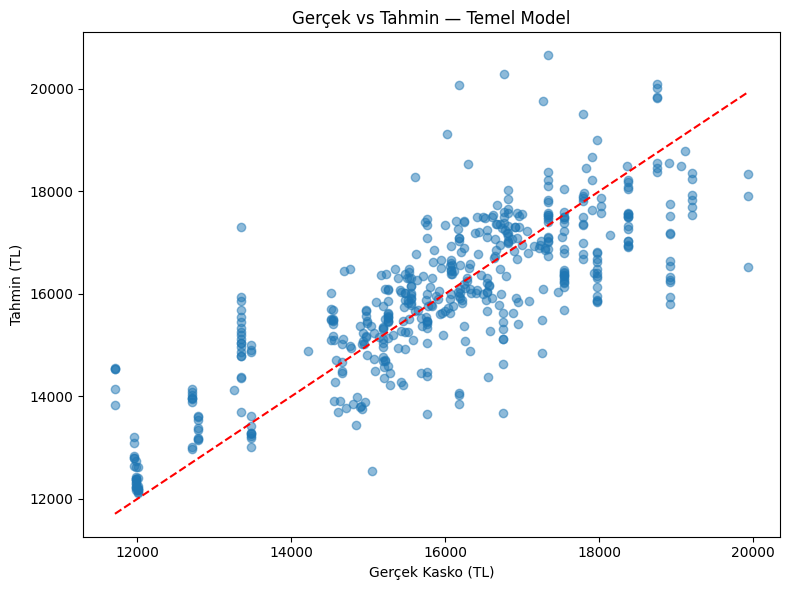

In [174]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test_real, y_pred_real, alpha=0.5)
plt.xlabel("Gerçek Kasko (TL)")
plt.ylabel("Tahmin (TL)")
plt.title("Gerçek vs Tahmin — Temel Model")
plt.plot([y_test_real.min(), y_test_real.max()],
         [y_test_real.min(), y_test_real.max()], 'r--')
plt.tight_layout()
plt.show()


## Modelin performansı neden düşük?


*   Log dönüşümünü geri alınca outlier değerler de geri geldi.


> Scatter tablosundan da anladığımız gibi, kasko düşükken modelin tahmini iyi ama fiyat yükseldikçe yanlış tahmin yapıyor..


*   Features yeterli değil, geliştirilmesi gerek



In [175]:
# 🔹 Outlier temizliği (%1 üstünü at)
df = df[df["Ortalama Kasko"] < df["Ortalama Kasko"].quantile(0.99)].copy()
df["Araç Yaşı"] = 2026 - df["Yıl"]  # df değişti, yeniden oluştur


In [176]:
df["Yaş_KM"]      = df["Araç Yaşı"] * df["Kilometre"]
df["Güç_Hacmi"]   = df["Motor Gücü"] * df["Motor Hacmi"]
df["Hasar_Oranı"] = df["paint_damage_score"] / (df["total_changed_parts"] + 1)

# ✅ features_v2 BAŞTAN tanımla
features_v2 = [
    "İlan Tarihi", "Tork", "Genişlik", "Motor Gücü", "Boş Ağırlığı",
    "Hızlanma (0-100)", "Jant Boyutu", "Seri", "Yakıt Deposu", "Yükseklik",
    "Model", "Maksimum Güç", "Uzunluk", "Sınıfı", "Fiyat",
    "Maksimum Hız", "Şehir İçi Yakıt Tüketimi", "Minimum Güç",
    "Aks Aralığı", "Motor Hacmi", "Araç Yaşı", "Kilometre",
    "paint_damage_score", "total_changed_parts", "is_fully_original",
    "Yaş_KM", "Güç_Hacmi", "Hasar_Oranı",
]
features_v2 += [col for col in df.columns if "Kasa Tipi_" in col]
features_v2 += [col for col in df.columns if "Çekiş_" in col]
features_v2 += [col for col in df.columns if "Yakıt Tipi_" in col]

X = df[features_v2]
y = df["Ortalama Kasko"]

# Polynomial Features
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# StandardScaler (Poly sonrası şart)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Ridge Regression (Poly sonrası LinearRegression overfitting yapar)
model = Ridge(alpha=100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [177]:
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae = mean_absolute_error(y_test_real, y_pred_real)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.2f} TL")
print(f"MAE:  {mae:,.2f} TL")
print(f"R²:   {r2:.4f}")

RMSE: 1,079.24 TL
MAE:  816.23 TL
R²:   0.8089


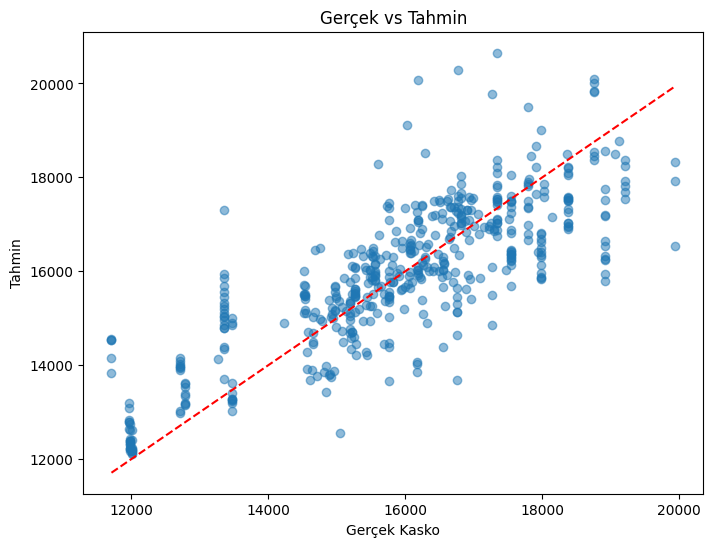

In [178]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test_real, y_pred_real, alpha=0.5)
plt.xlabel("Gerçek Kasko")
plt.ylabel("Tahmin")
plt.title("Gerçek vs Tahmin")

plt.plot(
    [y_test_real.min(), y_test_real.max()],
    [y_test_real.min(), y_test_real.max()],
    'r--'
)

plt.show()

### Performans çok daha iyi..

### polynomal feature sonrası scaling buna ek olarak Ridge/Lasso deneyelim

## Modelin

### 5. Actual vs Predicted Scatter Plot

This scatter plot compares actual kasko premiums with model predictions. Points close to the red diagonal line indicate accurate predictions.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual model outputs after training.

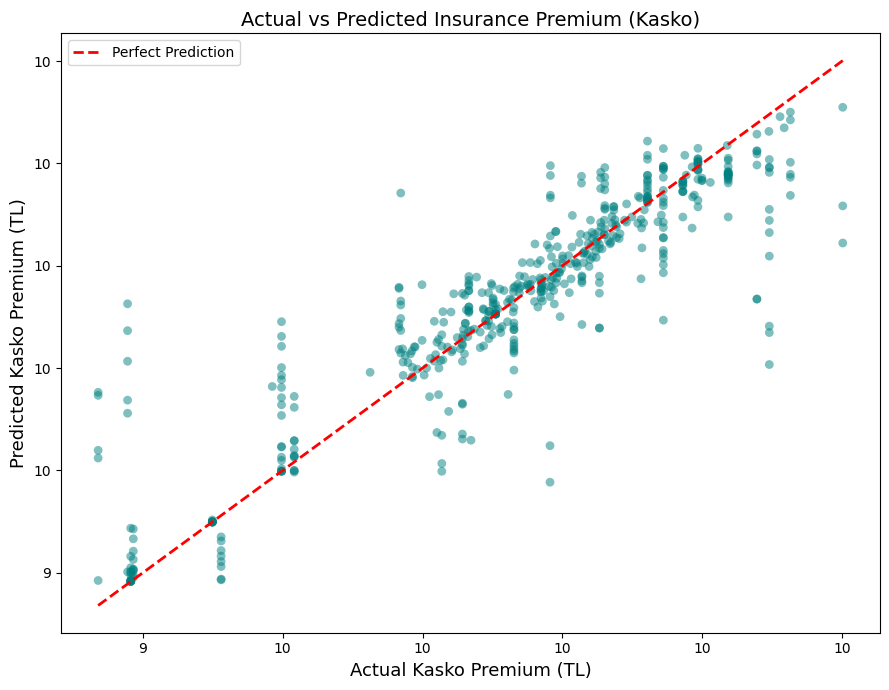

In [ ]:
# ⚠️ Replace y_test and y_pred with your actual outputs after training.
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(y_test, y_pred, alpha=0.5, color='teal', s=40, edgecolors='none')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Kasko Premium (TL)', fontsize=13)
ax.set_ylabel('Predicted Kasko Premium (TL)', fontsize=13)
ax.set_title('Actual vs Predicted Insurance Premium (Kasko)', fontsize=14)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

### 6. Residual Histogram

This histogram shows the distribution of residuals. A bell-shaped distribution centred near 0 suggests the model errors are approximately normally distributed.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual model outputs after training.

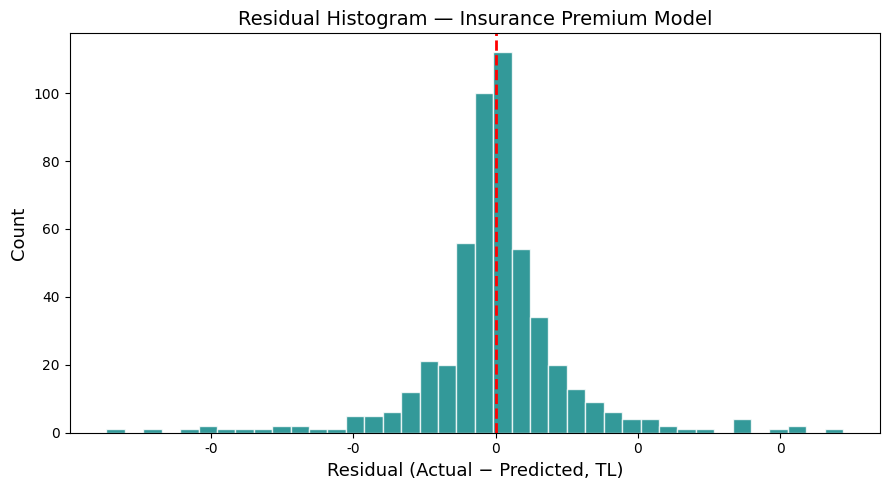

In [ ]:
# ⚠️ Replace y_pred and y_test with your actual outputs after training.
residuals = y_test - y_pred
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(residuals, bins=40, color='teal', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Residual (Actual − Predicted, TL)', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('Residual Histogram — Insurance Premium Model', fontsize=14)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()